In [14]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

with open("../data/model_results.pkl", "rb") as f:
    model_data = pickle.load(f)

y_test = model_data["y_test"]
y_pred_poly = model_data["y_pred_poly"]
y_pred_lr = model_data["y_pred_lr"]
X_train_poly = model_data["X_train_poly"]
y_train = model_data["y_train"]
results_table = model_data["results_table"]

print("Data loaded successfully!")
results_table

Data loaded successfully!


,Model,RMSE,MAE,R2,Adjusted_R2
0,Linear Regression,4.503,3.596,0.93010,0.92996
1,Ridge Regression,4.503,3.596,0.93011,0.92996
2,Lasso Regression,4.503,3.596,0.93010,0.92996
3,Polynomial Regression (deg=2),4.231,3.351,0.93828,0.93782
4,Polynomial Regression (deg=3),4.107,3.221,0.94184,0.94079


In [7]:
poly_model = model_data["poly_model"]
print("Polynomial Regression Intercept:", poly_model.intercept_)

Polynomial Regression Intercept: 453.23650751757685


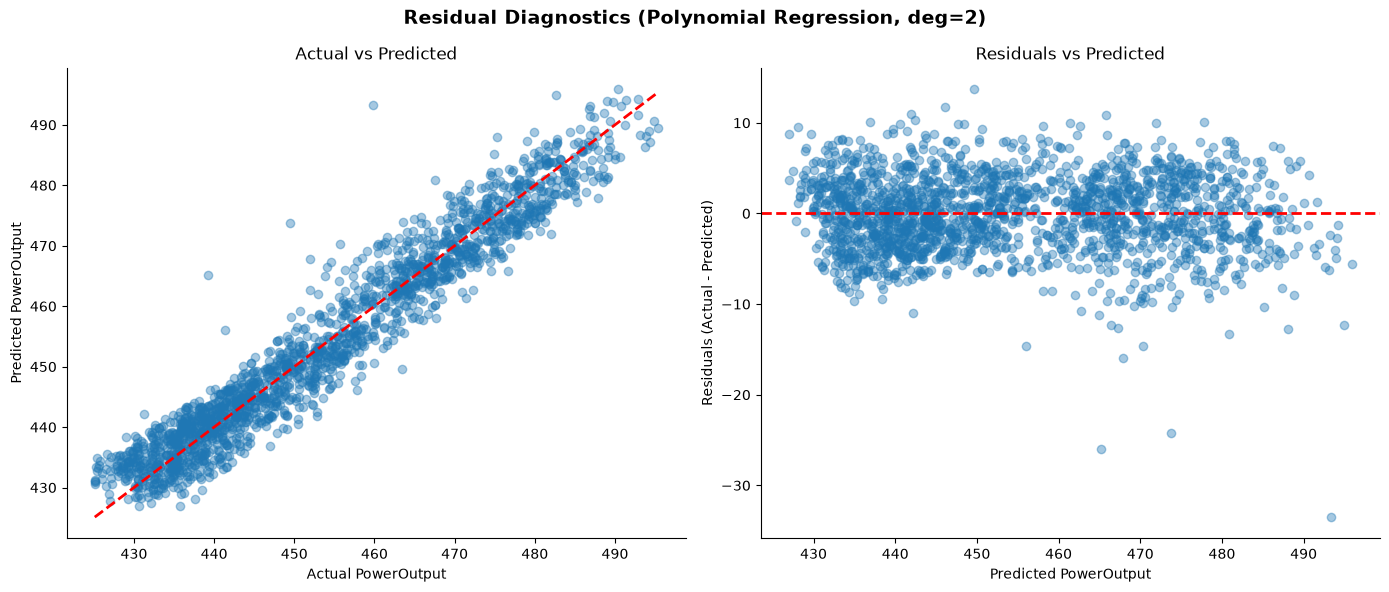

In [8]:
# Residual Diagnostics:

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_poly, alpha=0.4)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel("Actual PowerOutput")
axes[0].set_ylabel("Predicted PowerOutput")
axes[0].set_title("Actual vs Predicted")

# Residuals vs Predicted
residuals = y_test - y_pred_poly
axes[1].scatter(y_pred_poly, residuals, alpha=0.4)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel("Predicted PowerOutput")
axes[1].set_ylabel("Residuals (Actual - Predicted)")
axes[1].set_title("Residuals vs Predicted")

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle("Residual Diagnostics (Polynomial Regression, deg=2)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../images/08_residual_diagnostics.png", dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**

1. Points closely hug the diagonal across the full range (420–495 MW), consistent with R² = 0.938. Spread is fairly consistent throughout, with only a few isolated outliers and no signs of systematic bias.

2. Residuals scatter randomly around zero with no clear pattern or funnel shape, indicating consistent error variance across the prediction range (no major heteroscedasticity). A few outliers exist (residuals beyond -20), but they're rare and don't suggest a systematic issue.

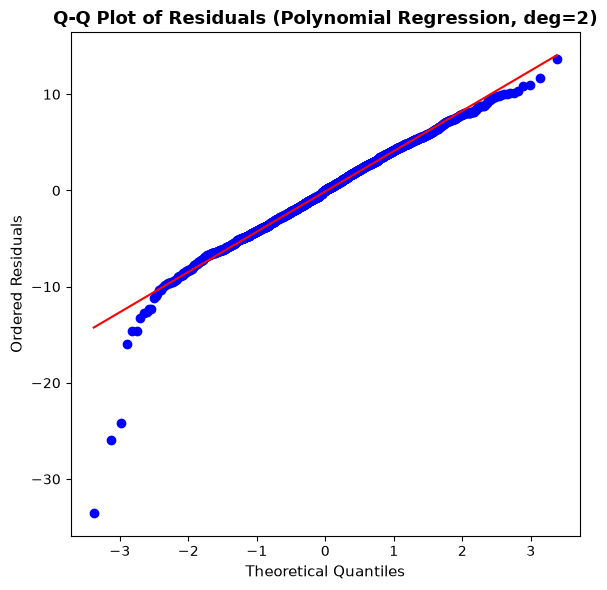

In [ ]:
import scipy.stats as stats

plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals (Polynomial Regression, deg=2)", fontsize=13, fontweight='bold')
plt.xlabel("Theoretical Quantiles", fontsize=11)
plt.ylabel("Ordered Residuals", fontsize=11)
plt.tight_layout()
plt.savefig("../images/09_qq_plot.png", dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**
Residuals are approximately normal for the vast majority of predictions, with only a small number of extreme cases deviating, not severe enough to undermine the model's overall validity.

In [15]:
# Cook's Diagnostics

import statsmodels.api as sm

# Add a constant (intercept) column, since statsmodels doesn't add one automatically
X_train_poly_sm = sm.add_constant(X_train_poly)

# Fit OLS in statsmodels
sm_model = sm.OLS(y_train.values, X_train_poly_sm).fit()

# Compute influence measures, including Cook's Distance
influence = sm_model.get_influence()
cooks_d = influence.cooks_distance[0]

# Threshold for "influential" points
n = len(y_train)
threshold = 4 / n

print(f"Number of influential points (Cook's D > {threshold:.5f}): {(cooks_d > threshold).sum()} out of {n}")

Number of influential points (Cook's D > 0.00052): 328 out of 7654


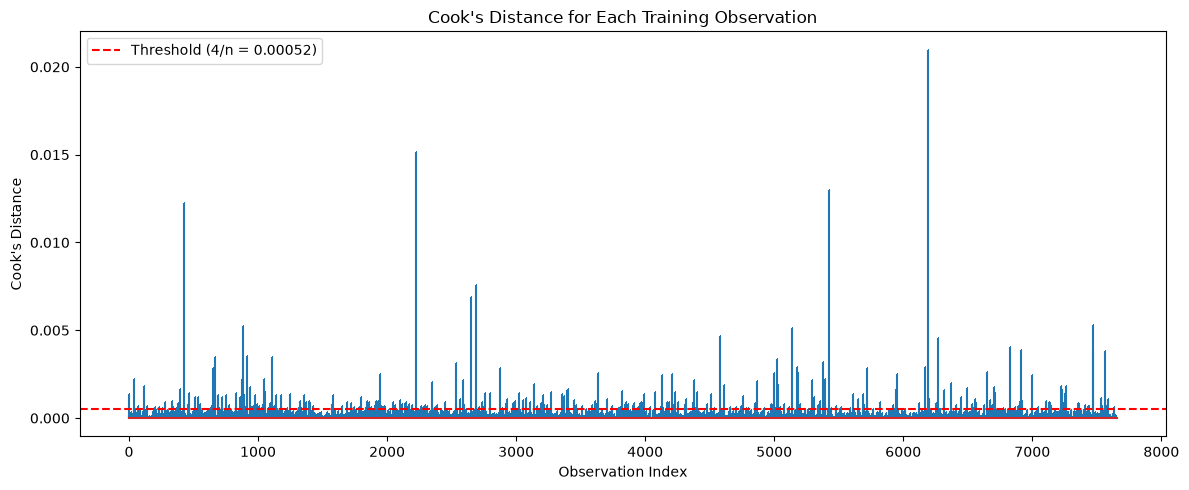

In [16]:
plt.figure(figsize=(12, 5))
plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",")
plt.axhline(y=threshold, color='r', linestyle='--', label=f'Threshold (4/n = {threshold:.5f})')
plt.xlabel("Observation Index")
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance for Each Training Observation")
plt.legend()
plt.tight_layout()
plt.savefig("../images/10_cooks_distance.png", dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**

Influential points (328 out of 7,654, ~4.3%) are scattered fairly randomly across the training set, with no clustering at specific index ranges this indicates they aren't tied to a particular time period or data segment, but rather represent individual unusual observations spread throughout the dataset.

A few points stand out with notably higher Cook's Distance (e.g., ~0.021 near index 6200, ~0.015 near index 2200), but even these remain small in absolute terms — well below the more conservative threshold of 1, suggesting no single observation is severely distorting the model.


**Regression Equations**

*Baseline: Linear Regression*

$$
\text{PowerOutput} = 454.569 - 1.986 \times \text{AmbientTemp} - 0.232 \times \text{ExhaustVacuum} + 0.062 \times \text{AmbientPressure} - 0.158 \times \text{RelativeHumidity}
$$

This is a simple linear combination of the 4 original features — each coefficient represents the change in `PowerOutput` (MW) for a 1-unit increase in that feature, holding all others constant.

---

*Final Model: Polynomial Regression (degree = 2)*

$$
\begin{aligned}
\text{PowerOutput} = 453.2365 
& - 13.404 \times \text{AT} - 3.811 \times \text{V} + 0.760 \times \text{AP} - 1.787 \times \text{RH} \\
& + 0.996 \times \text{AT}^2 + 0.978 \times (\text{AT} \times \text{V}) + 0.139 \times (\text{AT} \times \text{AP}) - 0.601 \times (\text{AT} \times \text{RH}) \\
& - 0.098 \times \text{V}^2 + 0.172 \times (\text{V} \times \text{AP}) + 0.013 \times (\text{V} \times \text{RH}) \\
& - 0.265 \times \text{AP}^2 - 0.316 \times (\text{AP} \times \text{RH}) - 0.411 \times \text{RH}^2
\end{aligned}
$$



*Note : (AT = AmbientTemp, V = ExhaustVacuum, AP = AmbientPressure, RH = RelativeHumidity are all scaled/standardized values, since this model was fit on `X_train_scaled`.)*

This expands the original 4 features into 14 terms allowing the model to capture curvature and combined effects between features that the baseline linear model couldn't represent.